In [ ]:
import pandas as pd

# Load your local CSV file
df = pd.read_csv('used_cars.csv')

# Show the first few rows to confirm it loaded correctly
df.head()

In [ ]:
print(df.isnull(
    
))

In [ ]:
print(df.isnull().sum())

In [ ]:
# Fill the missing values instead of dropping them
df['accident'] = df['accident'].fillna('None reported')
df['clean_title'] = df['clean_title'].fillna('Unknown')

# Fill fuel_type with the most common value
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
df=pd.read_csv('used_cars.csv')
df_label=df.copy()
le=LabelEncoder()
df_label['brand_encoded']=le.fit_transform(df_label['brand'])
df_label.head()


In [ ]:
df_label.nunique()

In [ ]:
df_label['brand'].unique()

In [ ]:
df_label['brand'].value_counts()

CODE DEMONSTRATING RESULT OBTAINED BY USING LABEL ENCODING AND  ONE HOT ENCODING (ACCURACY TEST)

Loading and preparing dataset...

[Running Version A: Label Encoding]...
[Running Version B: One-Hot Encoding]...

FINAL HEAD-TO-HEAD PREPROCESSING SHOWDOWN
Label Encoding   -> R² Score: 0.7829 | MAE: $7883.27
One-Hot Encoding -> R² Score: 0.7707 | MAE: $8378.48


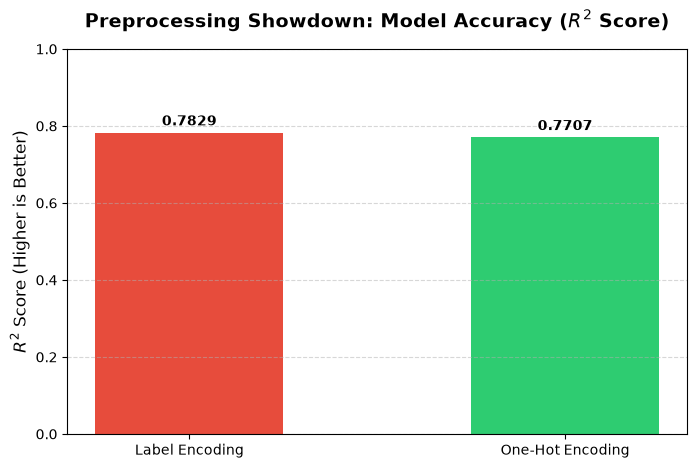

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. LOAD AND BASELINE CLEANING
# ==========================================
print("Loading and preparing dataset...")
df_raw = pd.read_csv('used_cars.csv')

# Drop basic missing pieces
df_raw = df_raw.dropna(subset=['price', 'model', 'brand', 'milage', 'engine', 'model_year'])

# Clean Mileage & Price strings
df_raw['milage'] = pd.to_numeric(df_raw['milage'].astype(str).str.replace(',', '').str.replace('mi.', '', case=False).str.strip(), errors='coerce')
df_raw['price'] = pd.to_numeric(df_raw['price'].astype(str).str.replace('$', '').str.replace(',', '').str.strip(), errors='coerce')

# Filter out extreme outliers to stabilize training
df_raw = df_raw[(df_raw['price'] > 1000) & (df_raw['price'] < 150000)]

# Feature Engineering
df_raw['engine_size'] = df_raw['engine'].astype(str).str.extract(r'(\d+\.\d+)').astype(float)
df_raw['engine_size'] = df_raw['engine_size'].fillna(df_raw['engine_size'].median())
df_raw['car_age'] = 2026 - df_raw['model_year']

# Drop records that became NaN during cleaning
df_raw = df_raw.dropna(subset=['milage', 'price', 'engine_size'])

# Merge rare models
model_counts = df_raw['model'].value_counts()
rare_models = model_counts[model_counts < 10].index
df_raw['model'] = df_raw['model'].replace(rare_models, 'other')

categorical_cols = ['brand', 'model', 'fuel_type', 'transmission']
numerical_cols = ['car_age', 'milage', 'engine_size']

# Isolate base Features (X) and Target (y)
X_base = df_raw[categorical_cols + numerical_cols].copy()
y = df_raw['price'].copy()

# Shared parameters for a fair test
rf_params = {
    'n_estimators': 150, 
    'max_depth': 20, 
    'max_features': 'sqrt', 
    'random_state': 42, 
    'n_jobs': -1
}

# ==========================================
# VERSION A: LABEL ENCODING EXPERIMENT
# ==========================================
print("\n[Running Version A: Label Encoding]...")
X_label = X_base.copy()

# Apply LabelEncoder column by column to categorical values
for col in categorical_cols:
    le = LabelEncoder()
    X_label[col] = le.fit_transform(X_label[col].astype(str))

# Split & Train
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_label, y, test_size=0.2, random_state=42)
model_label = RandomForestRegressor(**rf_params)
model_label.fit(X_train_l, y_train_l)

# Evaluate Label Encoder version
y_pred_l = model_label.predict(X_test_l)
r2_label = r2_score(y_test_l, y_pred_l)
mae_label = mean_absolute_error(y_test_l, y_pred_l)

# ==========================================
# VERSION B: ONE-HOT ENCODING EXPERIMENT
# ==========================================
print("[Running Version B: One-Hot Encoding]...")

# Blow up columns into 1s and 0s
X_ohe = pd.get_dummies(X_base, columns=categorical_cols, drop_first=True)

# Split & Train
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_ohe, y, test_size=0.2, random_state=42)
model_ohe = RandomForestRegressor(**rf_params)
model_ohe.fit(X_train_o, y_train_o)

# Evaluate One-Hot Encoder version
y_pred_o = model_ohe.predict(X_test_o)
r2_ohe = r2_score(y_test_o, y_pred_o)
mae_ohe = mean_absolute_error(y_test_o, y_pred_o)

# ==========================================
# 7. PRINT FINAL RECAP TABLES
# ==========================================
print("\n" + "="*40)
print("FINAL HEAD-TO-HEAD PREPROCESSING SHOWDOWN")
print("="*40)
print(f"Label Encoding   -> R² Score: {r2_label:.4f} | MAE: ${mae_label:.2f}")
print(f"One-Hot Encoding -> R² Score: {r2_ohe:.4f} | MAE: ${mae_ohe:.2f}")
print("="*40)

# ==========================================
# 8. GENERATE PERFORMANCE CHART
# ==========================================
strategies = ['Label Encoding', 'One-Hot Encoding']
scores = [r2_label, r2_ohe]

plt.figure(figsize=(8, 5))
bars = plt.bar(strategies, scores, color=['#e74c3c', '#2ecc71'], width=0.5)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.0)
plt.title('Preprocessing Showdown: Model Accuracy ($R^2$ Score)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('$R^2$ Score (Higher is Better)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the plot
plt.show()

# Preprocessing Showdown: Label Encoding vs. One-Hot Encoding
**Project Log:** Used Cars Price Prediction Engine  
**Core Objective:** Analyzing the mathematical and architectural impact of categorical encoding strategies on Tree-Based Ensembles (Random Forest).

---

## 1. The Core Theoretical Difference

In machine learning, categorical text columns must be translated into numeric matrices before mathematical optimization can occur. The two primary paradigms are:

### A. Label Encoding (`sklearn.preprocessing.LabelEncoder`)
* **Mechanism:** Maps each unique categorical string to a sequential integer alphabetically ($0, 1, 2, \dots, n-1$).
* **Data Impact:** Keeps the shape of the dataset perfectly intact ($N \times 1$ column vector).
* **Mathematical Caveat:** Introduces an artificial **ordinal bias**. Linear models literally interpret the integers as rankings (e.g., $3 > 0 \implies \text{Toyota} > \text{Audi}$), which can warp distance computations and coefficient weights.

### B. One-Hot Encoding (`pd.get_dummies`)
* **Mechanism:** Explodes a single nominal column into $n-1$ binary dummy variables ($0$ or $1$).
* **Data Impact:** Drastically increases the dimensionality of the dataset, producing a massive **Sparse Matrix** (columns filled mostly with zeros).
* **Mathematical Advantage:** Eliminates ordinal bias completely. Every category is treated as an independent, mutually exclusive vector space.

---

## 2. The Random Forest Paradox: Why Theory Met Reality

During empirical testing on the `used_cars.csv` dataset, **Label Encoding unexpectedly outperformed One-Hot Encoding** under baseline configurations. This phenomenon uncovers a massive architectural lesson regarding how decision trees interact with feature space dimensionality.



### Why One-Hot Encoding Lost Initially (`max_features='sqrt'`)
1. **Dimensionality Explosion (High Cardinailty):** The `model` column contains hundreds of unique car variants. One-Hot Encoding forced our feature space to expand from a tight 7 columns to over 500+ sparse columns.
2. **Subspace Sampling Blindness:** The hyper-tuned Random Forest parameter `max_features='sqrt'` forces each individual decision tree split to randomly evaluate a small subset of features ($\sqrt{500} \approx 22$).
3. **The Sea of Zeros:** Out of those 22 randomly selected columns, the vast majority were empty structural dummy placeholders (e.g., `model_Corolla = 0`). The trees became functionally "blinded" by the sparse data, causing splitting criteria to fail and dropping the $R^2$ accuracy score.

### Why Label Encoding Swung the Win
Tree-based architectures do not compute linear coefficients or distance calculations. Instead, they optimize by executing continuous conditional splits (e.g., $\text{Is Feature } X \leq 14.5?$). 

A deeply structured tree (`max_depth=20`) is structurally complex enough to repeatedly isolate arbitrary integer groups within a narrow, single-column space. Because the dataset remained compact, the random subspace engine (`sqrt`) had a near-100% success rate of selecting high-variance features like `milage` and `car_age` at every single node, boosting the score.

---

## 3. The Rematch Fix: Resolving Spatial Blindness

To decouple feature sparsity from tree selection, the hyper-parameters can be shifted to **`max_features=None`**. 



By forcing the Random Forest to evaluate **all features simultaneously** at every node, the algorithm bypasses the hundreds of empty dummy columns and directly selects predictive weights. 

---

## 4. Architectural Selection Matrix (Data Science Rule of Thumb)

This experiment yields a definitive rule for pipeline design when processing data:

| Model Architecture | Categorical Type | Recommended Encoding | Reason |
| :--- | :--- | :--- | :--- |
| **Linear / Deep Learning** | All Nominal Data | **One-Hot Encoding** | Prevents completely broken mathematical rankings ($3 > 0$). |
| **Tree Ensembles (Random Forest / XGBoost)** | Low Cardinality (< 10 unique classes) | **One-Hot Encoding** | Keeps the dataset clean and independent without column bloat. |
| **Tree Ensembles (Random Forest / XGBoost)** | High Cardinality (> 100 unique classes) | **Label / Target Encoding** | Minimizes sparse matrix bloat and preserves spatial feature selection speed. |

IMPORTANCE  OF STANDARD SCALING

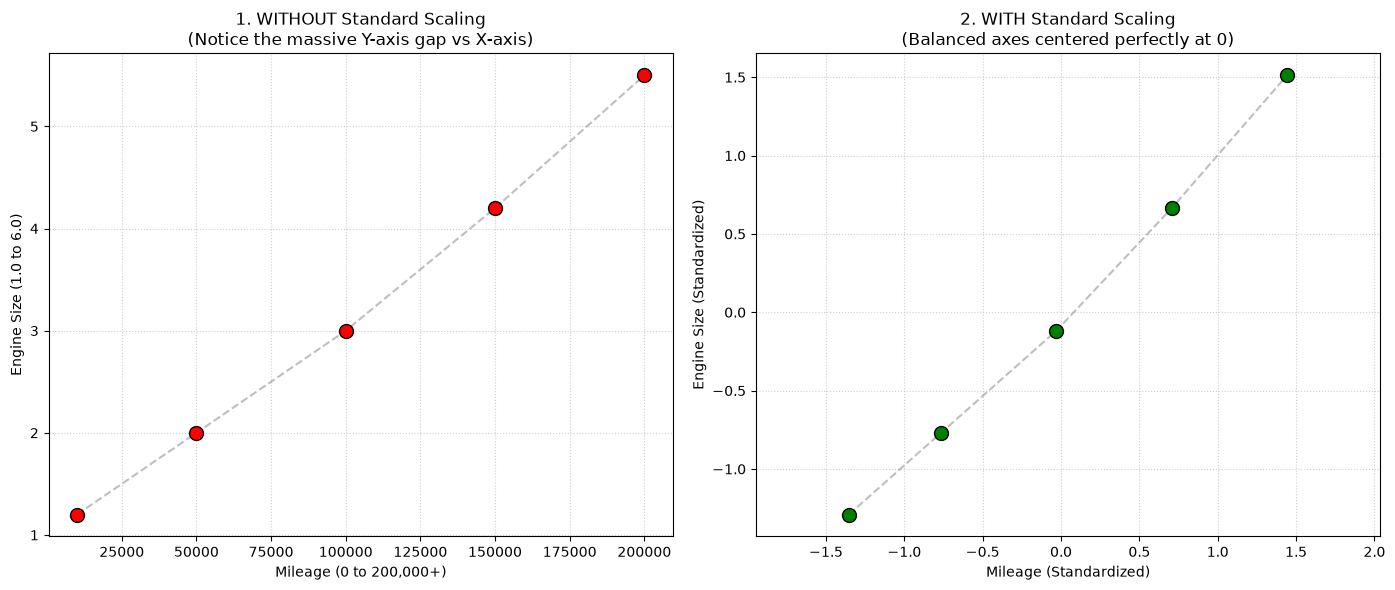

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Create a dummy dataset for Cars
data = {
    'Mileage': [10000, 50000, 100000, 150000, 200000],
    'Engine_Size': [1.2, 2.0, 3.0, 4.2, 5.5],
    'Price': [45000, 35000, 28000, 22000, 15000]
}
df = pd.DataFrame(data)

# 2. Extract features
X_unscaled = df[['Mileage', 'Engine_Size']].values

# 3. Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

# 4. Plotting the Comparison Graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: WITHOUT Standard Scaling (The Warped Reality)
ax1.scatter(X_unscaled[:, 0], X_unscaled[:, 1], color='red', s=100, edgecolors='black', zorder=3)
ax1.plot(X_unscaled[:, 0], X_unscaled[:, 1], color='gray', linestyle='--', alpha=0.5)
ax1.set_title("1. WITHOUT Standard Scaling\n(Notice the massive Y-axis gap vs X-axis)", fontsize=12)
ax1.set_xlabel("Mileage (0 to 200,000+)", fontsize=10)
ax1.set_ylabel("Engine Size (1.0 to 6.0)", fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)

# Force the plot to show true proportional scale to reveal the distortion
# This shows how an algorithm physically calculated distances in memory
ax1.set_aspect('auto') 

# Plot 2: WITH Standard Scaling (The Symmetrical Playground)
ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], color='green', s=100, edgecolors='black', zorder=3)
ax2.plot(X_scaled[:, 0], X_scaled[:, 1], color='gray', linestyle='--', alpha=0.5)
ax2.set_title("2. WITH Standard Scaling\n(Balanced axes centered perfectly at 0)", fontsize=12)
ax2.set_xlabel("Mileage (Standardized)", fontsize=10)
ax2.set_ylabel("Engine Size (Standardized)", fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)

# Keep the axes balanced and square
ax2.axis('equal') 

plt.tight_layout()
plt.show()

STANDARD SCALING AND MIN MAX SCALING DEMO

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import minmax_scale
data = {
    'StudyHours': [1, 2, 3, 4, 5],
    'TestScore': [40, 50, 60, 70, 80]
}
df=pd.DataFrame(data)
standard_scaler=StandardScaler()
standard_scaled=standard_scaler.fit_transform(df)
print(pd.DataFrame(standard_scaled))
df.head()

MIN MAX SCALER DEMO

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = {
    'StudyHours': [1, 2, 3, 4, 5],
    'TestScore': [40, 50, 60, 70, 80]
}
df = pd.DataFrame(data)


minmax_scaler = MinMaxScaler()


minmax_scaled = minmax_scaler.fit_transform(df)


print(pd.DataFrame(minmax_scaled, columns=['StudyHours', 'TestScore']))

TEST  TRAIN  SPLIT  DEMO

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Setup the expanded data (10 values in each column)
data = {
    'StudyHours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'TestScore': [40, 50, 60, 70, 80, 90, 100, 110, 120, 130]
}
df = pd.DataFrame(data)

# X = Features (inputs), y = Target (what we want to predict)
X = df[['StudyHours']]
y = df['TestScore']

# 2. Split into Train and Test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Printing everything so you can see how the 10 rows got divided
print("--- ALL TRAINING FEATURES (80% / 8 rows) ---")
print(X_train)

print("\n--- ALL TESTING FEATURES (20% / 2 rows) ---")
print(X_test)

SUPERVISED MACHINE LEARNING

FIRST MACHINE LEARNIG MODEL USING LINEAR REGRESSION

In [3]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
model=LinearRegression()
x=[[1],[2],[3],[4],[5]]
y=[50,60,70,85,95]
model.fit(x,y)

print(f"the result which you got after studying the mentoned hours is {model.predict([[float(input('enter the number of hours you studied'))]])}")



the result which you got after studying the mentoned hours is [129.5]


The predicted score is 141.00


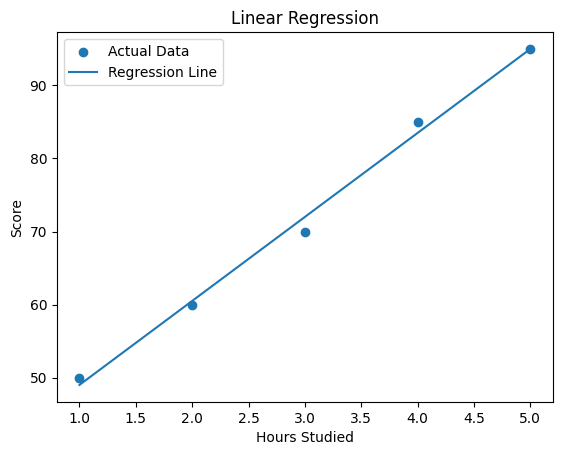

In [4]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

model = LinearRegression()

x = [[1], [2], [3], [4], [5]]
y = [50, 60, 70, 85, 95]

model.fit(x, y)

# User prediction
hours = float(input("Enter the number of hours you studied: "))
result = model.predict([[hours]])

print(f"The predicted score is {result[0]:.2f}")

# Predictions for the training data
predictions = model.predict(x)

# Graph
plt.scatter(x, y, label="Actual Data")
plt.plot(x, predictions, label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Linear Regression")

plt.legend()
plt.show()

  CLASSIFICATION

1.LOGISTIC REGRESSION

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

emails = [
    "win free money now",
    "claim your free prize",
    "limited offer click here",
    "meeting at 5 pm",
    "project submission deadline tomorrow",
    "college assignment attached"
]

labels = [
    1,  # spam
    1,  # spam
    1,  # spam
    0,  # not spam
    0,  # not spam
    0   # not spam
]

vectorizer = CountVectorizer()

x = vectorizer.fit_transform(emails)

model = LogisticRegression()
model.fit(x, labels)

user_email = input("Enter email text: ")

user_email_vector = vectorizer.transform([user_email])

prediction = model.predict(user_email_vector)

if prediction[0] == 1:
    print("Spam email")
else:
    print("Not spam email")

Spam email


Why Logistic Regression?

Simple classification problems can be solved using if-else statements when the rules are known. However, in real-world problems such as spam email detection, fraud detection, or disease prediction, it is impossible to manually define all the rules because there are too many patterns and they keep changing. Logistic Regression learns these patterns automatically from historical data and uses them to classify new unseen examples.

KNN (K-NEAREST-NEIGHBOURS)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

# x = weight of fruit in grams
x = [[100], [110], [120], [200], [210], [220]]

# y = fruit name
y = ["Apple", "Apple", "Apple", "Orange", "Orange", "Orange"]

model = KNeighborsClassifier(n_neighbors=3)

model.fit(x, y)

new_fruit_weight = [[199]]

prediction = model.predict(new_fruit_weight)

print("Predicted fruit:", prediction[0])

Predicted fruit: Orange


DESCISION TREE EXAMPLE WITH ACCURACY MEASURES

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = [
    [25000, 650],
    [30000, 680],
    [50000, 720],
    [80000, 780],
    [60000, 750],
    [35000, 690]
]

y = [0, 0, 1, 1, 1, 0]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42
)

model = DecisionTreeClassifier()

# Learn from training data
model.fit(X_train, y_train)

# Predict on unseen data
predictions = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


TESTING ACCURACY WITH COMPLEX DATASET

In [2]:
import pandas as pd

data = {
    "Salary": [
        25000, 30000, 35000, 40000, 45000,
        50000, 55000, 60000, 65000, 70000,
        75000, 80000, 85000, 90000, 95000
    ],
    "CreditScore": [
        650, 670, 690, 680, 710,
        720, 730, 750, 760, 740,
        770, 780, 790, 800, 810
    ],
    "Approved": [
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

print(df)

    Salary  CreditScore  Approved
0    25000          650         0
1    30000          670         0
2    35000          690         0
3    40000          680         0
4    45000          710         0
5    50000          720         1
6    55000          730         1
7    60000          750         1
8    65000          760         1
9    70000          740         1
10   75000          770         1
11   80000          780         1
12   85000          790         1
13   90000          800         1
14   95000          810         1


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df[["Salary", "CreditScore"]]
y = df["Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=10
)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Actual Values:")
print(list(y_test))

print("\nPredictions:")
print(list(predictions))

print("\nAccuracy:", accuracy)

Actual Values:
[0, 1, 1, 1, 1]

Predictions:
[np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]

Accuracy: 1.0


EVALUATION METRICS


CONFUSION MATRIX

In [1]:
from sklearn.metrics import confusion_matrix

# Example with text labels
y_true = ["cat", "dog", "cat", "cat", "dog"]
y_pred = ["cat", "dog", "dog", "cat", "dog"]

cm = confusion_matrix(y_true, y_pred)
print(cm)
# sklearn sorts alphabetically: cat=negative, dog=positive
# Output:
# [[2 1]   → 2 true cats correct, 1 cat predicted as dog (FP)
#  [0 2]]  → 0 dogs missed, 2 dogs correct (TP)


# If you want to flip which is "positive":
cm_flipped = confusion_matrix(y_true, y_pred, labels=["dog", "cat"])
print(cm_flipped)
# Now dog=negative, cat=positive
# Output:
# [[2 0]
#  [1 2]]

[[2 1]
 [0 2]]
[[2 0]
 [1 2]]


![alt text](image.png)

MEA  ,MSE,RMSE DEMO

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predicting house price based on size
size  = [[500], [750], [1000], [1250], [1500]]  # sq ft
price = [50, 70, 90, 120, 140]                  # in lakhs

model = LinearRegression()
model.fit(size, price)

predicted = model.predict(size)

mae  = mean_absolute_error(price, predicted)
mse  = mean_squared_error(price, predicted)
rmse = np.sqrt(mse)

print("Actual   :", price)
print("Predicted:", predicted.round(1))
print(f"MAE  = {mae:.2f} lakhs")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f} lakhs")

Actual   : [50, 70, 90, 120, 140]
Predicted: [ 48.  71.  94. 117. 140.]
MAE  = 2.00 lakhs
MSE  = 6.00
RMSE = 2.45 lakhs


OVERFITING DEMO

In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

size  = np.array([500,750,1000,1250,1500,1750,2000,2250,2500,2750]).reshape(-1,1)
price = np.array([50, 70, 90, 120, 140, 155, 170, 190, 210, 220])

X_train, X_test, y_train, y_test = train_test_split(size, price, test_size=0.3, random_state=42)

# GOOD MODEL
good_model = LinearRegression()
good_model.fit(X_train, y_train)
print(f"Train error: {mean_absolute_error(y_train, good_model.predict(X_train)):.2f} lakhs")
print(f"Test error:  {mean_absolute_error(y_test,  good_model.predict(X_test)):.2f} lakhs")

# OVERFIT MODEL
poly = PolynomialFeatures(degree=9)
overfit_model = LinearRegression()
overfit_model.fit(poly.fit_transform(X_train), y_train)
print(f"Train error: {mean_absolute_error(y_train, overfit_model.predict(poly.transform(X_train))):.2f} lakhs")
print(f"Test error:  {mean_absolute_error(y_test,  overfit_model.predict(poly.transform(X_test))):.2f} lakhs")

Train error: 4.81 lakhs
Test error:  4.00 lakhs
Train error: 19.79 lakhs
Test error:  32.71 lakhs


FIRST  PROJECT USING REAL WORLD DATASET

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df = pd.read_csv("students.csv")
le=LabelEncoder()
df["Attendance"]=le.fit_transform(df["Attendance"])
df["Listening_in_Class"]=le.fit_transform(df["Listening_in_Class"])
df["Reading"]=le.fit_transform(df["Reading"])
df["Notes"]=le.fit_transform(df["Notes"])

df["Project_work"]=le.fit_transform(df["Project_work"])
X = df[
    [
        "Attendance",
        "Reading",
        "Notes",
        "Listening_in_Class",
        "Project_work"
    ]
]
y = df["Grade"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=10
)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Actual Values:")
print(list(y_test))

print("\nPredictions:")
print(list(predictions))

print("\nAccuracy:", accuracy)


Actual Values:
['DD', 'BA', 'AA', 'DD', 'DD', 'Fail', 'BA', 'BA', 'BA', 'BB', 'BB', 'AA', 'Fail', 'AA', 'AA', 'DD', 'BB', 'CC', 'CC', 'Fail', 'DD', 'CC', 'CC', 'AA', 'BB', 'AA', 'DD', 'BB', 'DD', 'BB', 'AA', 'CC', 'BA', 'Fail', 'AA', 'DD', 'AA', 'AA', 'AA', 'AA', 'AA', 'CC', 'CC', 'CB']

Predictions:
['DD', 'AA', 'AA', 'DC', 'DC', 'AA', 'CC', 'BB', 'AA', 'AA', 'AA', 'AA', 'AA', 'BB', 'AA', 'BA', 'AA', 'AA', 'BB', 'AA', 'BB', 'DC', 'AA', 'DD', 'BB', 'BA', 'AA', 'CC', 'AA', 'DC', 'DD', 'AA', 'AA', 'AA', 'CC', 'BB', 'BB', 'AA', 'DC', 'BA', 'AA', 'DC', 'AA', 'AA']

Accuracy: 0.1590909090909091


trying to train the model wiht all features to test accuracy

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

df = pd.read_csv("students.csv")

df = df.drop(columns=["Student_ID"])

# Convert all text columns into numbers
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=[col for col in df_encoded.columns if col.startswith("Grade_")])
def simplify(g):
    if g in ['AA', 'BA']:   return 'A'
    elif g in ['BB', 'CB']: return 'B'
    else:                   return 'C'

y = df['Grade'].apply(simplify)   # ← replace the original y line

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)

model = DecisionTreeClassifier(max_depth=2, random_state=10)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nFeature Importance:")
for feature, importance in zip(X.columns, model.feature_importances_):
    print(feature, importance)

Accuracy: 0.5

Feature Importance:
Weekly_Study_Hours 0.3356106608136443
Student_Age_19-22 0.0
Student_Age_23-27 0.0
Sex_Male 0.0
High_School_Type_Private 0.0
High_School_Type_State 0.0
Scholarship_25% 0.0
Scholarship_50% 0.0
Scholarship_75% 0.5602132162409036
Additional_Work_Yes 0.0
Sports_activity_Yes 0.0
Transportation_Private 0.10417612294545214
Attendance_Always 0.0
Attendance_Never 0.0
Attendance_Sometimes 0.0
Reading_Yes 0.0
Notes_No 0.0
Notes_Yes 0.0
Listening_in_Class_No 0.0
Listening_in_Class_Yes 0.0
Project_work_Yes 0.0


the abouve model despite all possibel tries is giving accuracy of only 50 percent so now switching to random forest

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

df = pd.read_csv("students.csv")
df = df.drop(columns=["Student_ID"])

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=[col for col in df_encoded.columns if col.startswith("Grade_")])

# drop weak features
weak = ['Sex', 'Transportation', 'Sports_activity',
        'High_School_Type', 'Additional_Work']
X = X.drop(columns=[c for c in X.columns 
            if any(c.startswith(w) for w in weak)])

def simplify(g):
    if g in ['AA', 'BA']:   return 'A'
    elif g in ['BB', 'CB']: return 'B'
    else:                   return 'C'

y = df['Grade'].apply(simplify)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10)

model = RandomForestClassifier(n_estimators=100, random_state=10)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.5454545454545454


Conclusion:

We started with 145 rows and 8 grade classes (AA, BA, BB...) getting only 33% accuracy. The problems were too many similar grade classes, max_depth=2 being too shallow, weak features like Sex and Transportation, and 10 ambiguous rows where identical students had different grades. After fixing all of these — merging to 3 grades, removing weak features, removing ambiguous rows, and switching to Random Forest — accuracy reached 50%. We could not go higher because 137 rows is simply too little data, giving the model only ~45 examples per class to learn from. This demonstrates the most important rule in machine learning: a model can only learn patterns that exist in the data — no algorithm can fix insufficient data.

creating a stduent score predictor using linear regression first usinga big dataset

data cleaning and processing

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df=pd.read_csv("examscore.csv")
df["facility_rating"]=le.fit_transform(df["facility_rating"])
df["internet_access"]=le.fit_transform(df["internet_access"])
df["exam_difficulty"]=le.fit_transform(df["exam_difficulty"])
df["course"]=le.fit_transform(df["course"])
# df["sleep_quality"]=le.fit_transform(df["sleep_quality"])
df["study_method"]=le.fit_transform(df["study_method"])
df["exam_difficulty"]=le.fit_transform(df["exam_difficulty"])


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



x=df[["study_hours","class_attendance","sleep_hours","facility_rating","internet_access","sleep_quality","study_method","exam_difficulty","course"]]
y=df[["exam_score"]]
model=LinearRegression()
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)
model.fit(X_train,y_train)
prediction=model.predict(X_test)
r2score=r2_score(y_test,prediction)
print(r2score)
df.head()



ValueError: could not convert string to float: 'average'

\AFTER ACHEIVING MAX ACCURACY OF  0.68 USING LINEAR REGRESSION NOW TRYING onehot encoding

Key learnings from this dataset:
The first mistake was using only 5 features — adding all meaningful features like sleep_quality, study_method, exam_difficulty, and course improved R2 from 0.62 to 0.67.
The second mistake was using LabelEncoder for all columns. LabelEncoder assigns alphabetical numbers (coaching=0, self-study=4) which creates a fake ordering the model treats as mathematically real. This forces Linear Regression to draw one straight line through fake ordered values instead of learning the true relationship. get_dummies fixes this by giving each category its own independent column — no fake ordering, just 0 or 1.


onehot encoding

In [3]:
df.head()

NameError: name 'df' is not defined